### How can we improve the downscaling algorithm?

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [28]:
pil_image = Image.open('cat_large.jpg')
image = np.array(pil_image)
print(image.shape)
def better_downscale(image, scale_factor):
    h, w, c = image.shape #height, width, color

    h = (h // scale_factor) * scale_factor
    w = (w // scale_factor) * scale_factor

    image = image[:h, :w]
                        #(세로 블록 개수, 블록 내부 세로 픽셀, 가로 블록 개수, 블록 내부 가로 픽셀,RGB)
    small = image.reshape(h // scale_factor, scale_factor, w // scale_factor, scale_factor,c).mean(axis=(1,3))

    return small.astype(np.uint8) #평균내면 자료형이 float니까 dtype int로 바꾸기
                #astype : 넘파이배열의 자료형을 바꾸는 함수


(1280, 1920, 3)


(128, 192, 3)


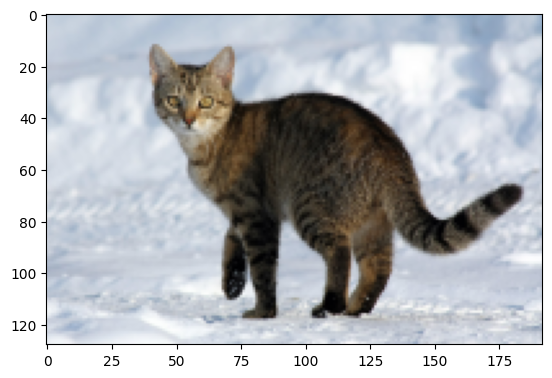

In [30]:
downscaled_image = better_downscale(image, 10) #이 함수에 저장
plt.imshow(downscaled_image[:,:,:]) #출력
print(downscaled_image.shape)